In [1]:
# Import necessary libraries
import pandas as pd
from collections import defaultdict
import geopandas as gpd
from shapely import wkt
import shapely

import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import pickle
%matplotlib inline
import datetime
import time
import numpy as np
import xml.etree.ElementTree as ET 
import matsim

import utm
from shapely.geometry import Polygon, Point
import gzip
from matplotlib import cm

import matplotlib.ticker as ticker
import matplotlib.font_manager as font_manager
import matplotlib as mpl
from matplotlib.lines import Line2D
from tqdm import tqdm
from matplotlib.colors import LinearSegmentedColormap


In [2]:
import ast
result = pd.read_csv("result_2.csv")

def determine_area_type(raumtyp):
    if raumtyp in [1, 2, 3]:
        return 'Urban'
    elif raumtyp in [4, 5, 6]:
        return 'Suburban'
    elif raumtyp in [7, 8]:
        return 'Rural'
    else:
        return 'unknown'

# Umbenennen der Spalten für besser lesbare KPIs
rename_map = {
    'tour_km': 'Tour Length (km)',
    'Tour Duration': 'Tour Duration (hrs)',
    'Travel Duration': 'Driving Time (hrs)',
    'vehicle_load_factor': 'Vehicle Utilization (%)',
    'initial_delivery_distance': 'Initial Delivery Distance (km)',
    'avg_dist_wo_init': 'Mean Delivery Distance Between Stops (km)'
}
result = result.rename(columns=rename_map)

# Konvertiere Sekunden → Stunden (nur wenn noch nicht konvertiert)
for col in ['Tour Duration (hrs)', 'Driving Time (hrs)']:
    result[col] = result[col] / 3600

# Durchschnittsgeschwindigkeit berechnen (km/h)
result['Average Speed (km/h)'] = result['Tour Length (km)'] / result['Driving Time (hrs)']

result['main_area_type_agg'] = result['main_area_type'].apply(determine_area_type)
# Prozentualer Anteil der reinen Fahrzeit an der Gesamttourdauer
result['Driving Share of Tour (%)'] = (result['Driving Time (hrs)'] / result['Tour Duration (hrs)']) * 100




In [3]:
bc = result.copy()

In [4]:
import re
import ast
from collections import defaultdict

def parse_defaultdict_string(val):
    if isinstance(val, str):
        match = re.search(r"\{.*\}", val)
        if match:
            try:
                parsed_dict = ast.literal_eval(match.group(0))
                return defaultdict(int, parsed_dict)
            except:
                return defaultdict(int)
        else:
            return defaultdict(int)
    elif isinstance(val, dict):
        return defaultdict(int, val)
    elif isinstance(val, defaultdict):
        return val
    return defaultdict(int)

bc['raumsplit_parsed'] = bc['raumsplit'].apply(parse_defaultdict_string)


In [5]:
from collections import defaultdict

def collapse_to_main_if_dominant(rs, threshold=0.95):
    total = sum(rs.values())
    if total == 0:
        return rs  # leer lassen, nichts machen
    dominant_type, dominant_count = max(rs.items(), key=lambda item: item[1])
    if dominant_count / total >= threshold:
        return defaultdict(int, {dominant_type: total})  # alles diesem Typ zuweisen
    return rs  # sonst unverändert lassen

# anwenden
bc['raumsplit_parsed_dom'] = bc['raumsplit_parsed'].apply(collapse_to_main_if_dominant)


In [6]:
bc['num_raumtypen'] = bc['raumsplit_parsed_dom'].apply(lambda x: len(x))


In [8]:
# Define the category_dict
category_dict = {
    "1": "Metropolitan Center",
    "2": "High-Density Residential Use",
    "3": "Dense Mixed Use",
    "4": "Residential Use",
    "5": "Industrial Use",
    "6": "Urbanized Periphery",
    "7": "Rural with Industrial Influence",
    "8": "Rural without Industrial Influence"
}
# Map the numbers to the area descriptions
bc['main_area_type_desc'] = bc['main_area_type'].astype(str).map(category_dict)

In [11]:
def determine_area_type(raumtyp):
    if raumtyp in [1, 2, 3]:
        return 'Urban'
    elif raumtyp in [4, 5, 6]:
        return 'Suburban'
    elif raumtyp in [7, 8]:
        return 'Rural'
    else:
        return 'unknown'
    
bc['area_type_agg'] = bc['main_area_type'].apply(determine_area_type)

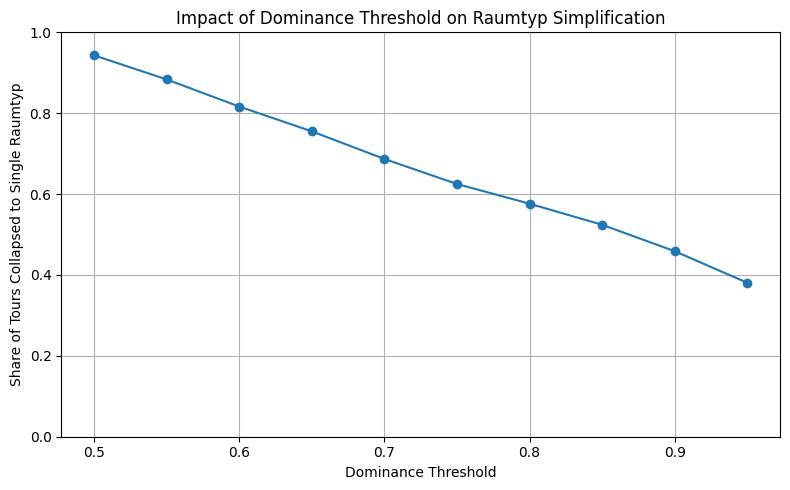

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# Funktion, um raumsplit zu vereinfachen
def collapse_to_main_if_dominant(rs, threshold):
    total = sum(rs.values())
    if total == 0:
        return rs
    dominant_type, dominant_count = max(rs.items(), key=lambda item: item[1])
    if dominant_count / total >= threshold:
        return defaultdict(int, {dominant_type: total})
    return rs

# Schwellenwerte
thresholds = np.arange(0.5, 1.0, 0.05)
single_type_shares = []

for t in thresholds:
    collapsed = bc['raumsplit_parsed'].apply(lambda x: collapse_to_main_if_dominant(x, t))
    n_single = collapsed.apply(lambda x: len(x) == 1).sum()
    share = n_single / len(bc)
    single_type_shares.append(share)

# Plotten
plt.figure(figsize=(8, 5))
plt.plot(thresholds, single_type_shares, marker='o')
plt.xlabel('Dominance Threshold')
plt.ylabel('Share of Tours Collapsed to Single Raumtyp')
plt.title('Impact of Dominance Threshold on Raumtyp Simplification')
plt.grid(True)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


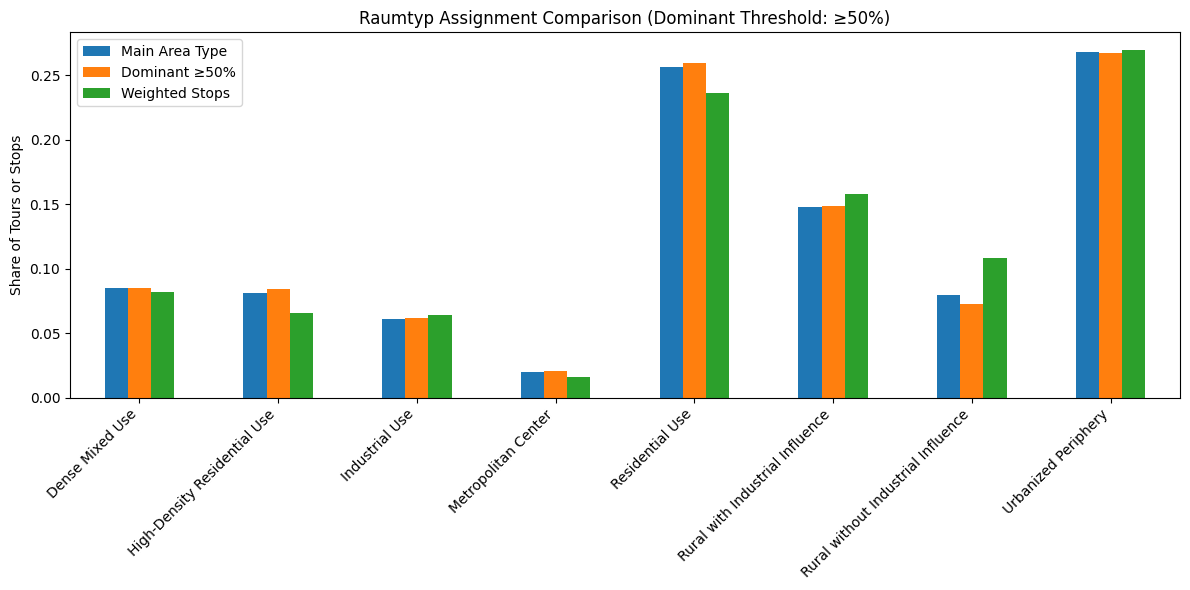

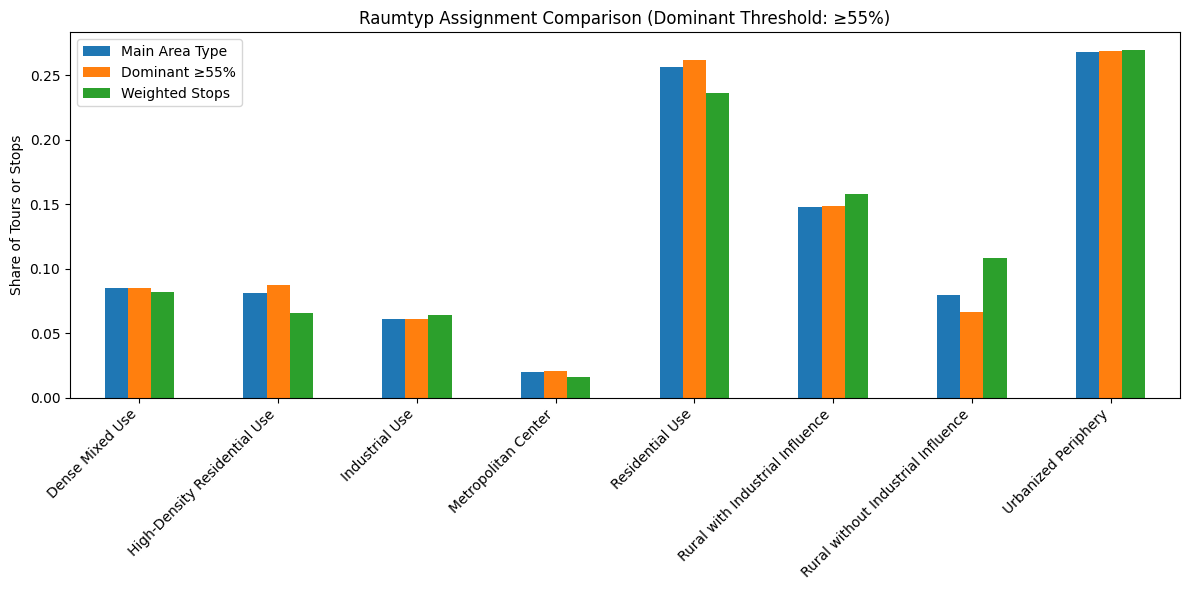

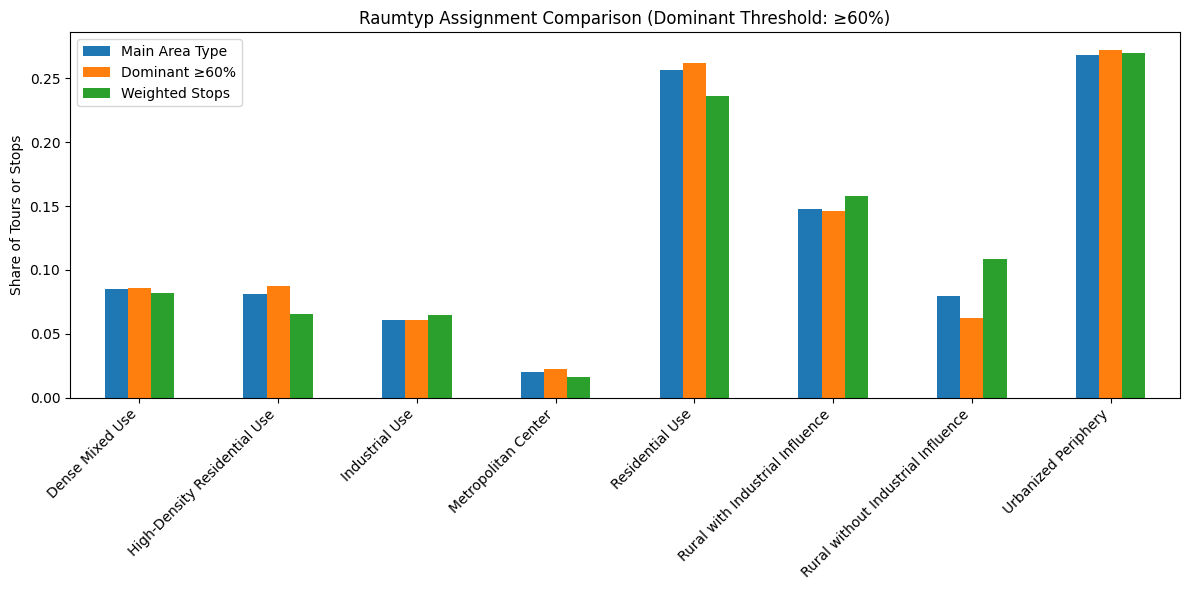

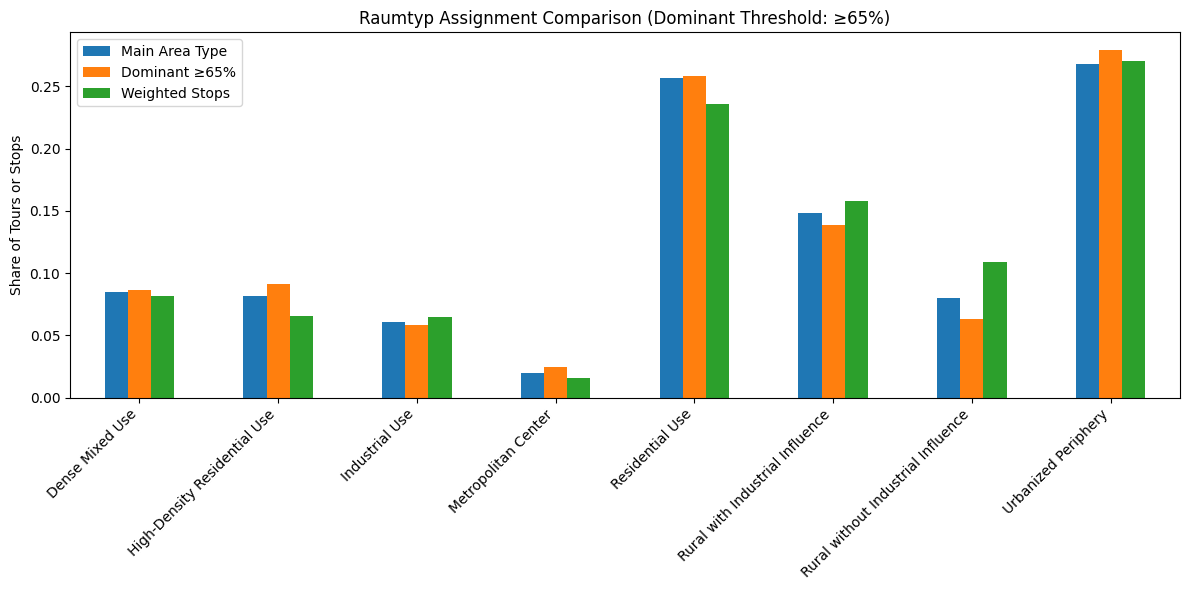

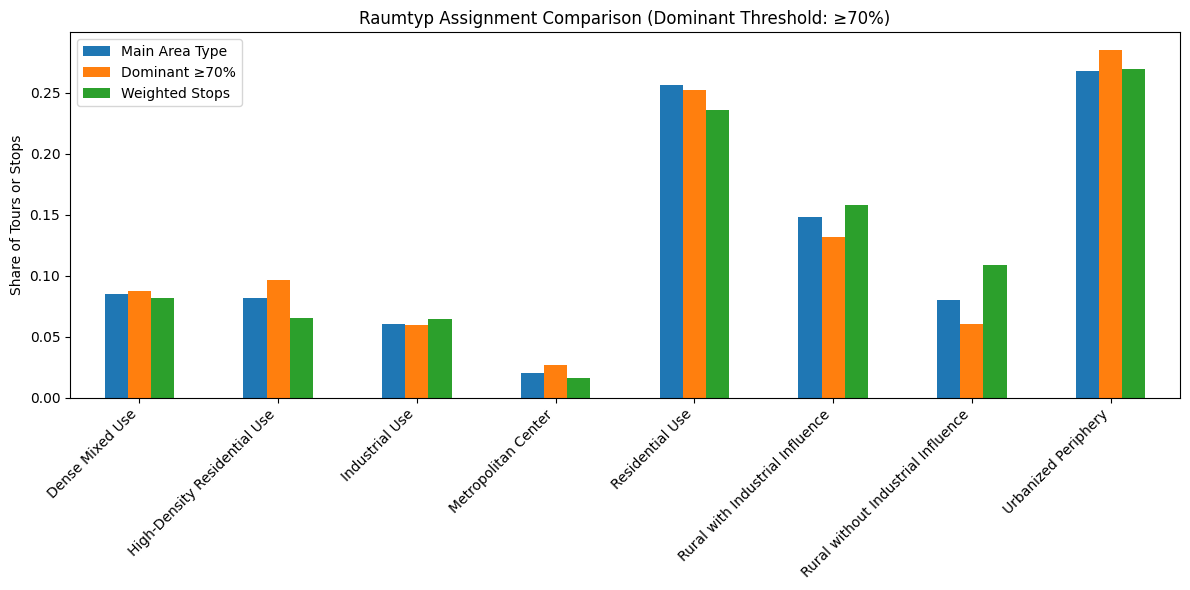

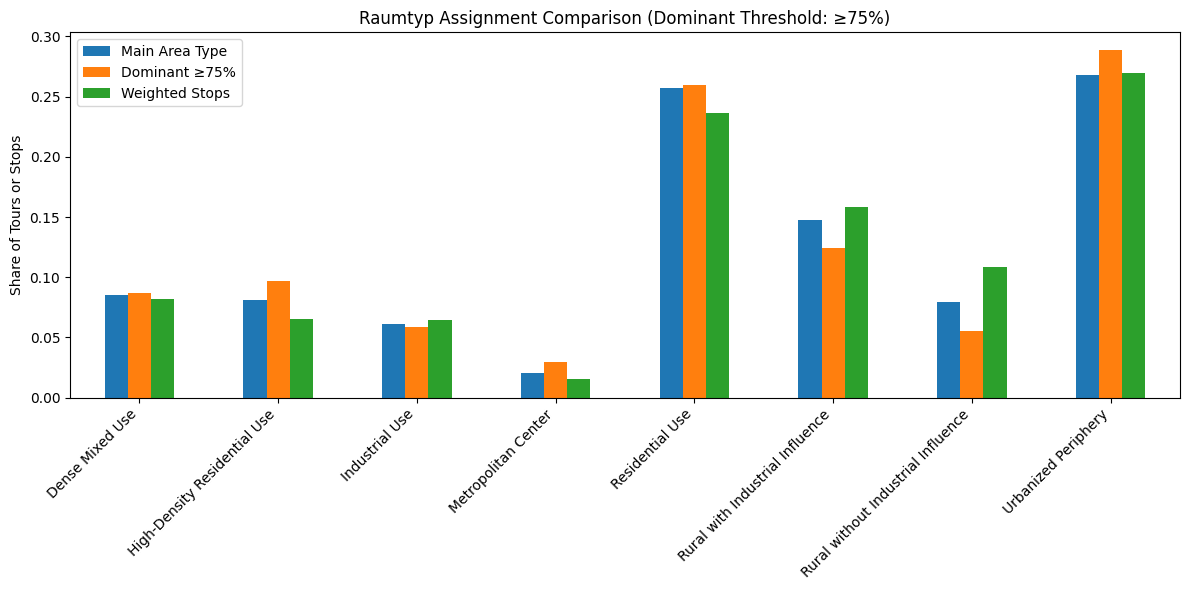

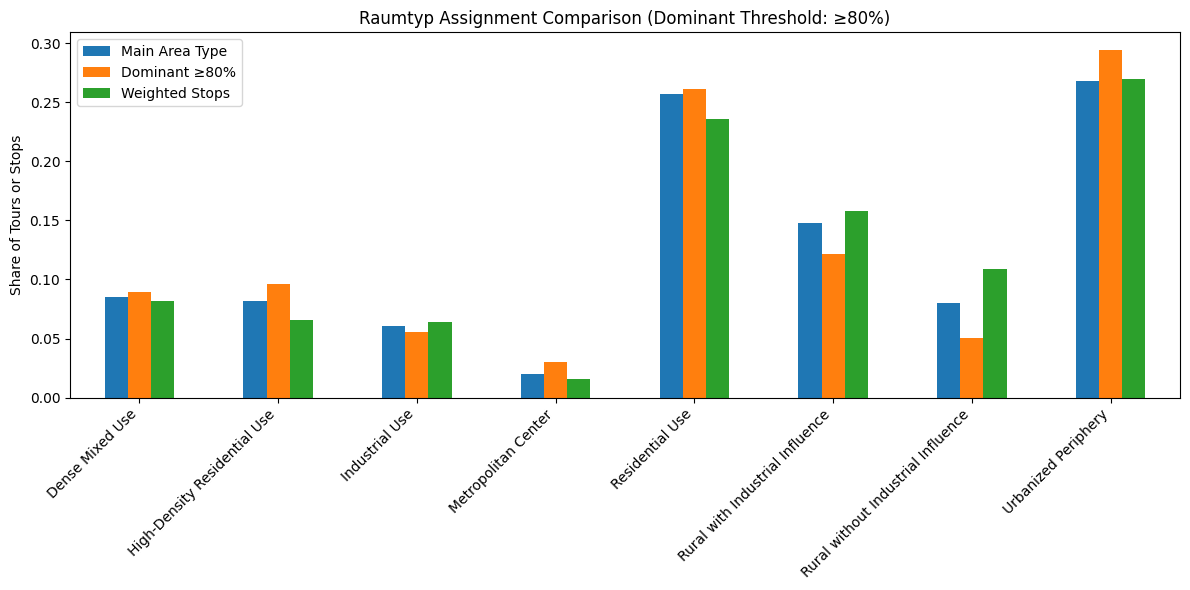

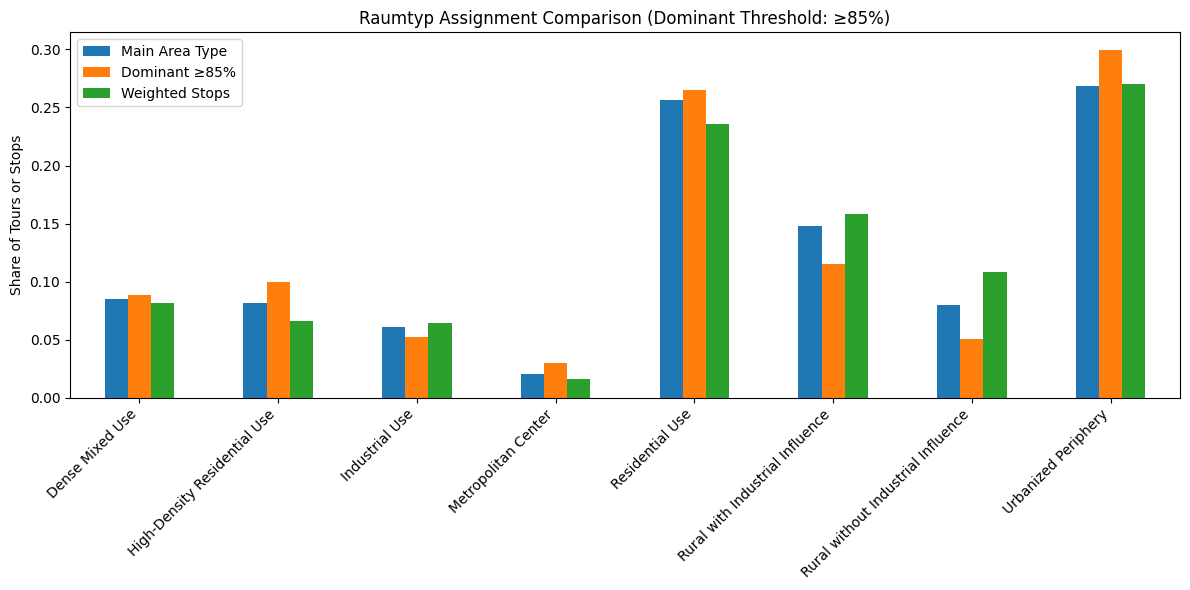

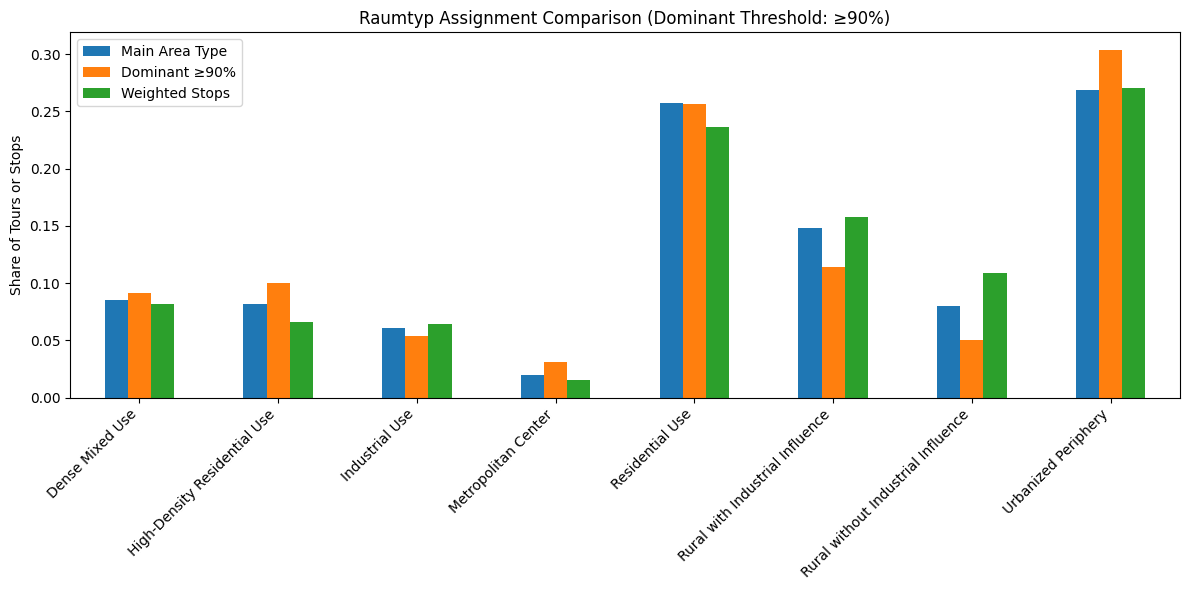

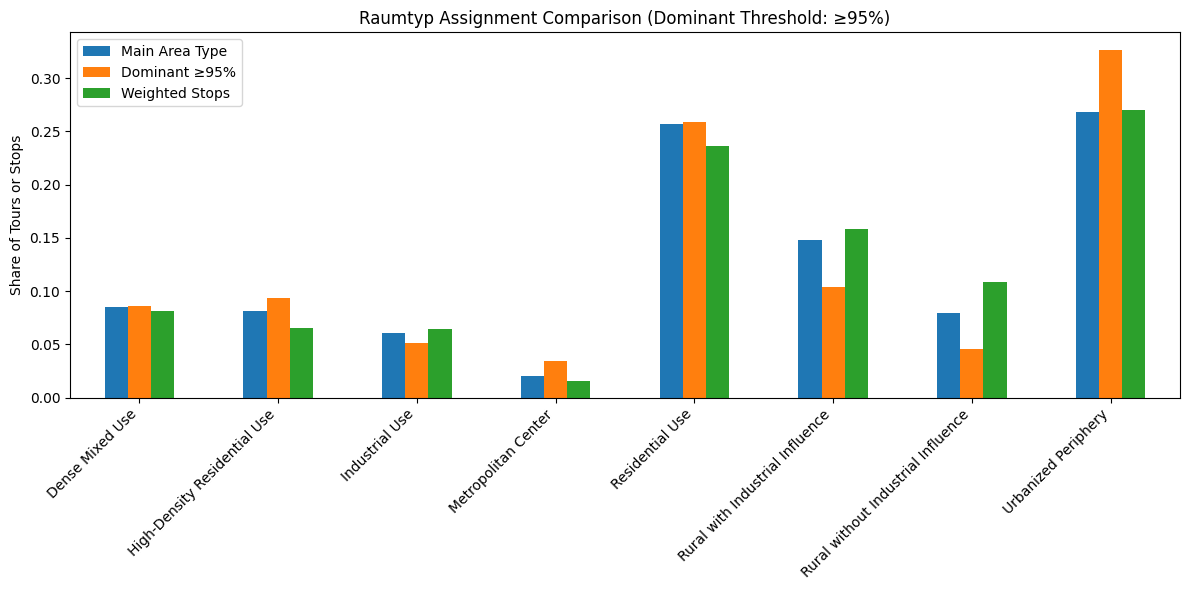

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict, Counter

# Raumtyp-Beschriftung
area_type_mapping = {
    1: "Metropolitan Center",
    2: "High-Density Residential Use",
    3: "Dense Mixed Use",
    4: "Residential Use",
    5: "Industrial Use",
    6: "Urbanized Periphery",
    7: "Rural with Industrial Influence",
    8: "Rural without Industrial Influence"
}

# Main Area Type
tour_counts_main = bc['main_area_type_desc'].value_counts(normalize=True).sort_index()

# Weighted (nach Stops)
counter = Counter()
for d in bc['raumsplit_parsed']:
    total = sum(d.values())
    if total > 0:
        for k, v in d.items():
            counter[k] += v
total_stops = sum(counter.values())
weighted_counts = {area_type_mapping[k]: v / total_stops for k, v in sorted(counter.items())}
weighted_series = pd.Series(weighted_counts, name='Weighted Stops')

# Thresholds analysieren
thresholds = np.arange(0.5, 1.0, 0.05)

for t in thresholds:
    # Dominanzzuweisung bei Schwelle t
    def collapse_to_main_if_dominant(rs):
        total = sum(rs.values())
        if total == 0:
            return None
        dominant_type, dominant_count = max(rs.items(), key=lambda item: item[1])
        if dominant_count / total >= t:
            return dominant_type
        return None  # Tour ist nicht eindeutig zuweisbar

    bc['dominant_area_thresh'] = bc['raumsplit_parsed'].apply(collapse_to_main_if_dominant)
    dominant_series = (
        bc['dominant_area_thresh'].dropna()
        .astype(int)
        .map(area_type_mapping)
        .value_counts(normalize=True)
        .sort_index()
        .rename(f'Dominant ≥{int(t*100)}%')
    )

    # Kombinieren
    df_compare = pd.concat([
        tour_counts_main.rename('Main Area Type'),
        dominant_series,
        weighted_series
    ], axis=1).fillna(0)

    # Plot
    df_compare.plot(kind='bar', figsize=(12, 6))
    plt.ylabel("Share of Tours or Stops")
    plt.title(f"Raumtyp Assignment Comparison (Dominant Threshold: ≥{int(t*100)}%)")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


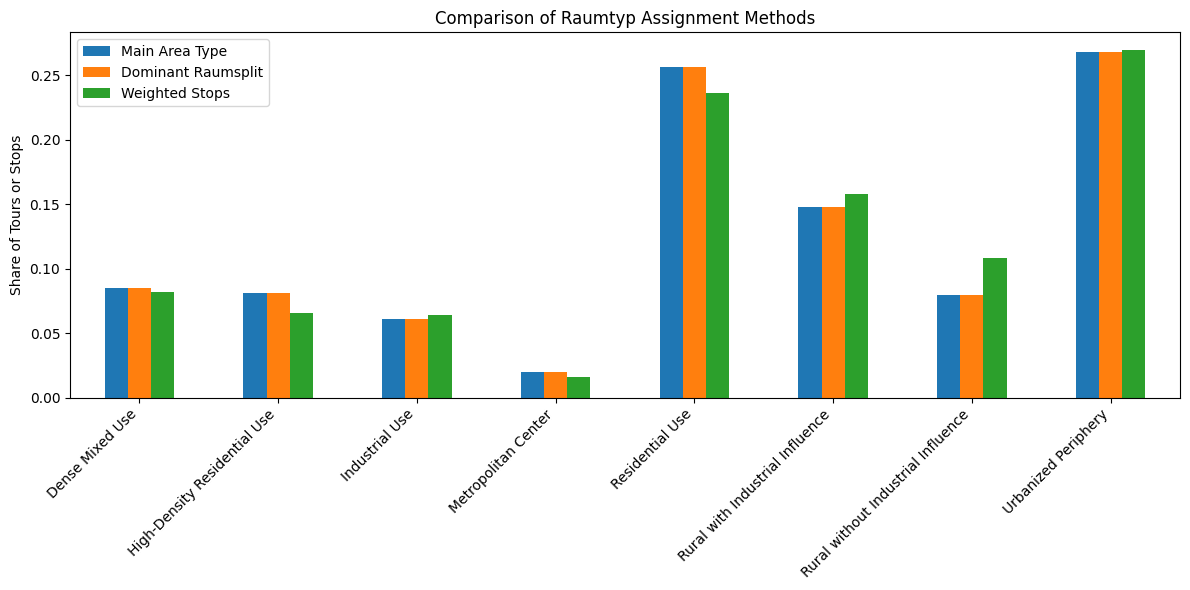

In [14]:
tour_counts_main = bc['main_area_type_desc'].value_counts(normalize=True).sort_index()

bc['dominant_area'] = bc['raumsplit_parsed'].apply(
    lambda d: max(d.items(), key=lambda x: x[1])[0] if d else None
)
area_type_mapping = {
    1: "Metropolitan Center",
    2: "High-Density Residential Use",
    3: "Dense Mixed Use",
    4: "Residential Use",
    5: "Industrial Use",
    6: "Urbanized Periphery",
    7: "Rural with Industrial Influence",
    8: "Rural without Industrial Influence"
}

bc['dominant_area_desc'] = bc['dominant_area'].map(area_type_mapping)
tour_counts_dominant = bc['dominant_area_desc'].value_counts(normalize=True).sort_index()
from collections import Counter

counter = Counter()
for d in bc['raumsplit_parsed']:
    total = sum(d.values())
    if total > 0:
        for k, v in d.items():
            counter[k] += v

# in Prozentanteile überführen
total_stops = sum(counter.values())
weighted_counts = {area_type_mapping[k]: v / total_stops for k, v in sorted(counter.items())}


import pandas as pd
import matplotlib.pyplot as plt

df_compare = pd.DataFrame({
    'Main Area Type': tour_counts_main,
    'Dominant Raumsplit': tour_counts_dominant,
    'Weighted Stops': pd.Series(weighted_counts)
}).fillna(0)

df_compare.plot(kind='bar', figsize=(12, 6))
plt.ylabel("Share of Tours or Stops")
plt.title("Comparison of Raumtyp Assignment Methods")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



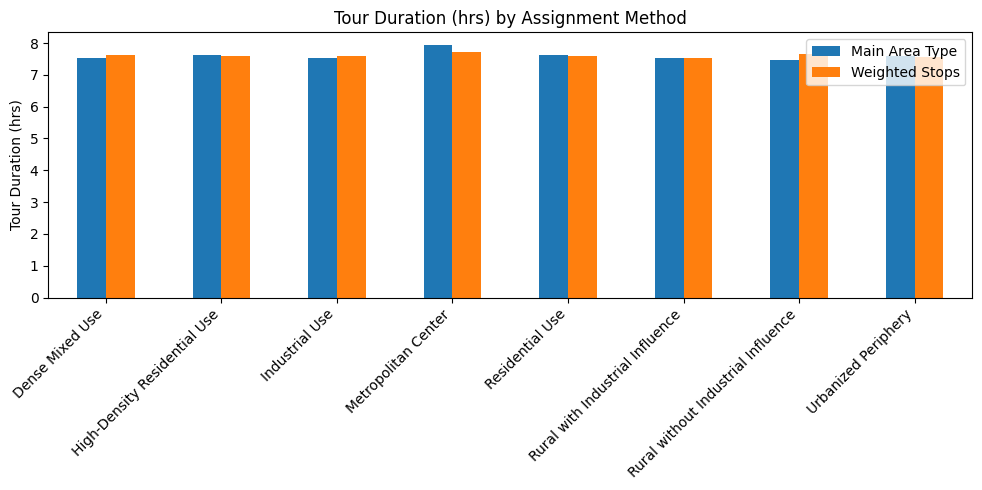

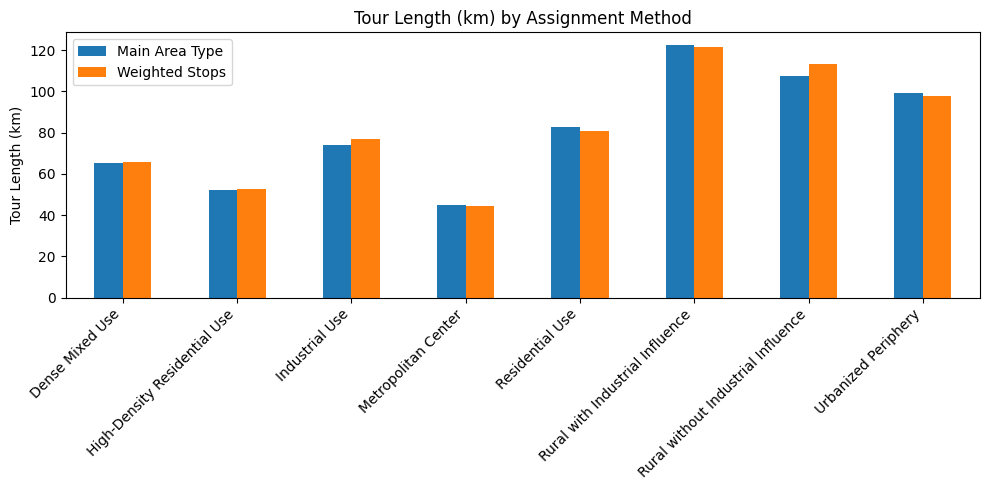

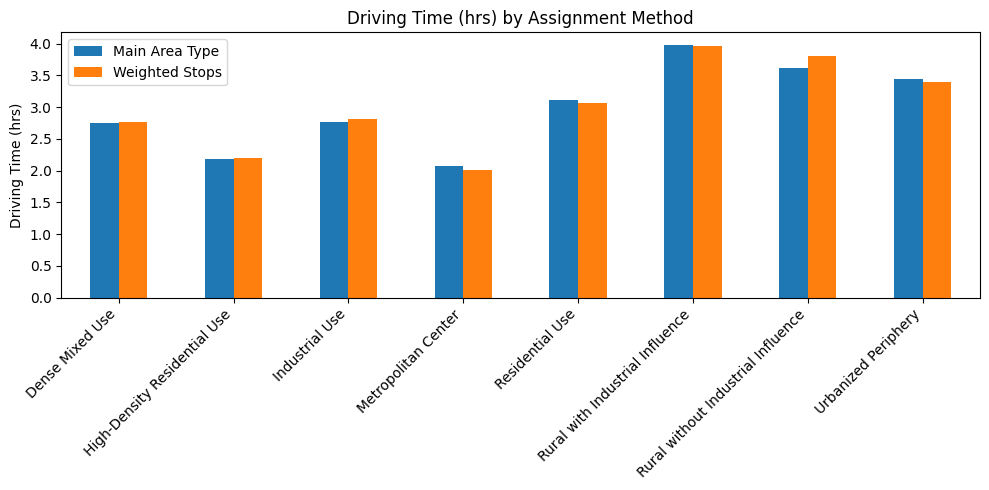

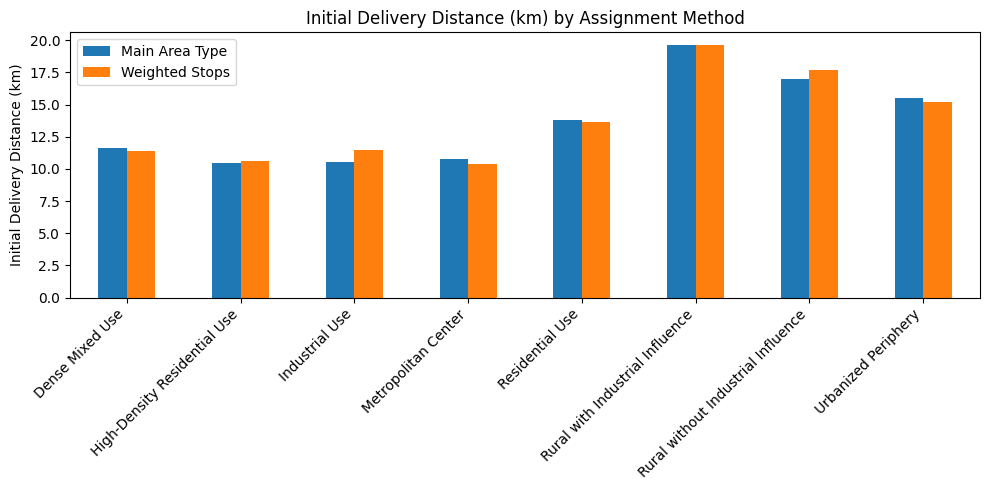

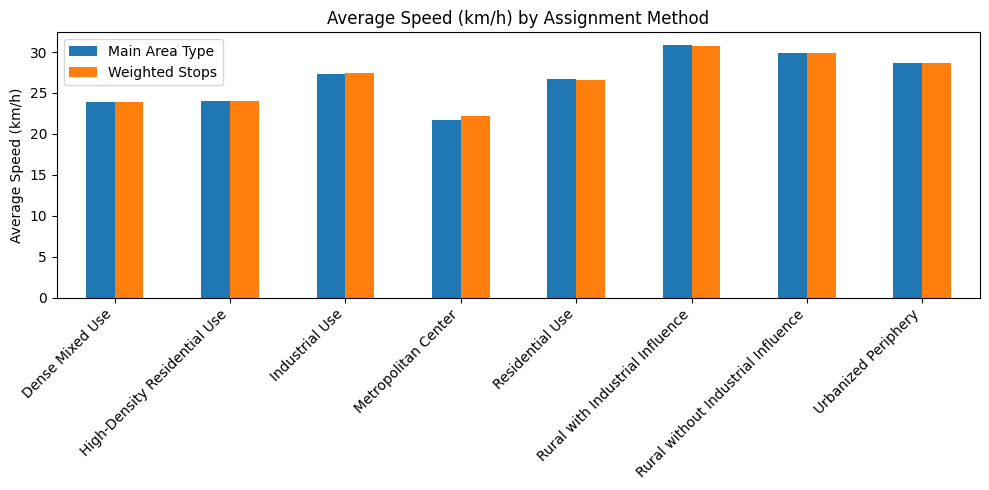

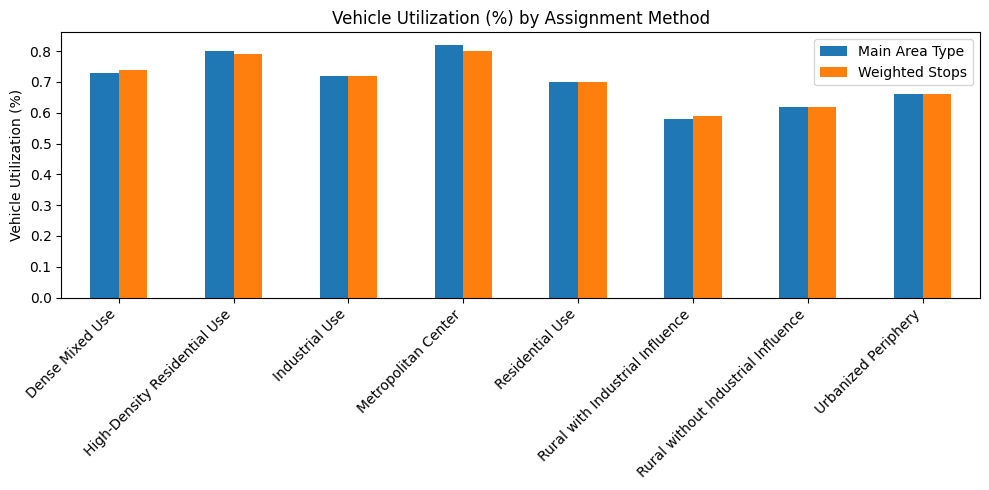

In [15]:
from collections import defaultdict
import pandas as pd
import matplotlib.pyplot as plt

# Liste deiner Kalibrierungs-KPIs
kpi_columns = [
    "Tour Duration (hrs)",
    "Tour Length (km)",
    "Driving Time (hrs)",
    "Initial Delivery Distance (km)",
    "Average Speed (km/h)",
    "Vehicle Utilization (%)"
]

# Mapping für Raumtypen
area_type_mapping = {
    1: "Metropolitan Center",
    2: "High-Density Residential Use",
    3: "Dense Mixed Use",
    4: "Residential Use",
    5: "Industrial Use",
    6: "Urbanized Periphery",
    7: "Rural with Industrial Influence",
    8: "Rural without Industrial Influence"
}

# Ensure desc columns
bc['main_area_type_desc'] = bc['main_area_type'].astype(int).map(area_type_mapping)

# Sensitivitätsanalyse speichern
sensitivity_results = {}

for kpi in kpi_columns:
    # --- Methode 1: Tour → Main Area ---
    main_series = (
        bc.groupby('main_area_type_desc')[kpi]
        .mean()
        .rename('Main Area Type')
    )

    # --- Methode 2: Gewichteter KPI über raumsplit ---
    weighted_sum = defaultdict(float)
    weighted_count = defaultdict(float)

    for _, row in bc.iterrows():
        rs = row['raumsplit_parsed']
        total = sum(rs.values())
        if total > 0:
            for k, v in rs.items():
                weight = v / total
                weighted_sum[k] += row[kpi] * weight
                weighted_count[k] += weight

    weighted_avg = {
        area_type_mapping[k]: weighted_sum[k] / weighted_count[k]
        for k in weighted_sum
    }
    weighted_series = pd.Series(weighted_avg, name='Weighted Stops')

    # --- Kombinieren + Abweichung berechnen ---
    df_compare = pd.concat([main_series, weighted_series], axis=1)
    df_compare["Abs. Difference"] = (df_compare["Main Area Type"] - df_compare["Weighted Stops"]).abs()
    df_compare["Rel. Difference (%)"] = (
        df_compare["Abs. Difference"] / df_compare["Main Area Type"]
    ) * 100
    df_compare = df_compare.round(2)

    # --- Speichern für Übersicht ---
    sensitivity_results[kpi] = df_compare

    # --- Optional: Plot für jede Metrik ---
    df_compare[["Main Area Type", "Weighted Stops"]].plot(
        kind="bar", figsize=(10, 5), title=f"{kpi} by Assignment Method"
    )
    plt.ylabel(kpi)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


In [16]:
for kpi in kpi_columns:
    print(f"\n--- {kpi} ---")
    # print(sensitivity_results[kpi])
    print("Relative Difference (%):", sensitivity_results[kpi]["Rel. Difference (%)"].mean())




--- Tour Duration (hrs) ---
Relative Difference (%): 1.1087500000000001

--- Tour Length (km) ---
Relative Difference (%): 2.0300000000000002

--- Driving Time (hrs) ---
Relative Difference (%): 1.96

--- Initial Delivery Distance (km) ---
Relative Difference (%): 2.80625

--- Average Speed (km/h) ---
Relative Difference (%): 0.42375

--- Vehicle Utilization (%) ---
Relative Difference (%): 0.67125
